# Atrial tachycardia ablation

An electrical wave travels around an atrial opening and returns to tissue that can be excited again. If we interrupt its route with an ablation line, will activation stop—or find another way around the atrium [[1]](https://doi.org/10.1161/CIRCEP.124.013102)?

Here, we explore that question through two simulations on the same atrial mesh. We prepare one initial activation pattern, then compare lesions connecting different anatomical openings. This is an illustrative experiment using Finitewave and the Courtemanche model; it does not reproduce the papers' simulations or calculate their boundary phase indices.

[[1] Duytschaever, Mattias, et al. "Atrial topology for a unified understanding of typical and atypical flutter." Circulation: Arrhythmia and Electrophysiology 17.11 (2024): e013102.](https://doi.org/10.1161/CIRCEP.124.013102)

## Start with the anatomy

Before following the wave, we need to see the routes available to it. Load `data/atrial_points.npy` and `data/atrial_elems.npy`, then extract the boundary loops around the openings. The code identifies the mitral valve (MV, red), left superior pulmonary vein (LSPV, green), and right inferior pulmonary vein (RIPV, blue).

These names are assigned by loop size for this particular mesh. Check the colored geometry before carrying the same assignments over to another atrium.

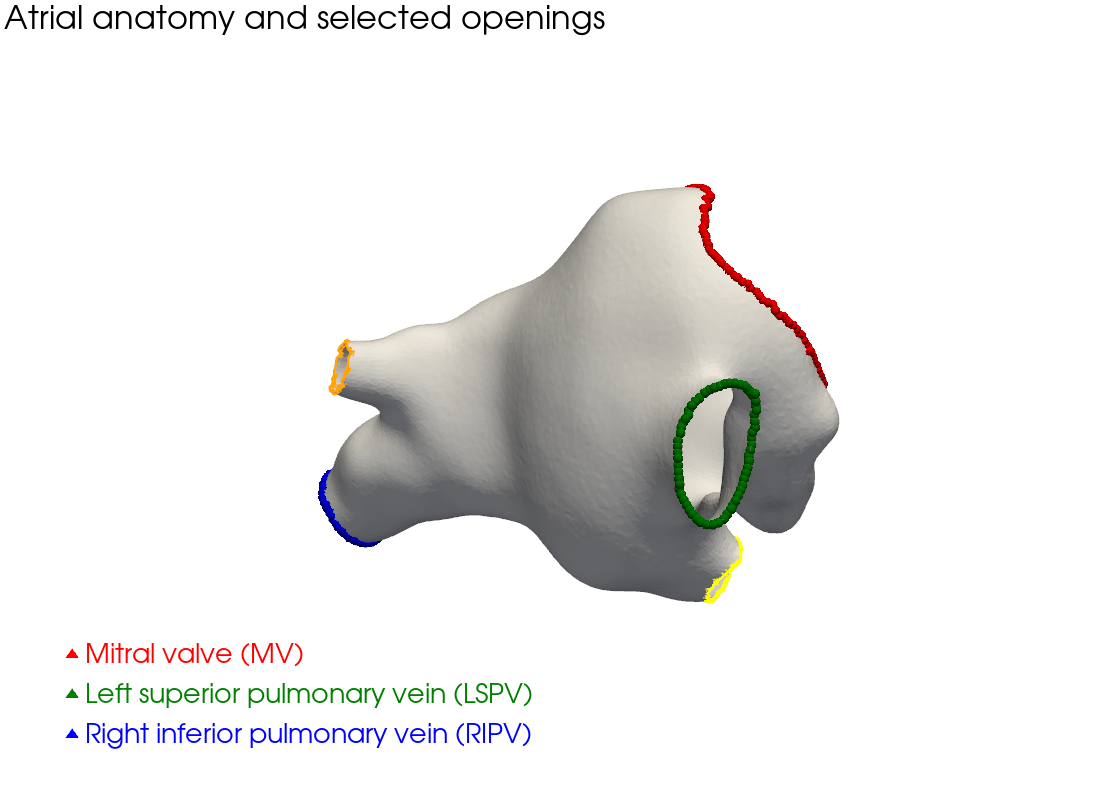

In [21]:
from pathlib import Path
import numpy as np
import pyvista as pv


path = Path("./data")

points = np.load(path / "atrial_points.npy")
elems = np.load(path / "atrial_elems.npy")

camera_position = [(-159.069, -285.733, 86.216),
                   (-33.103, -27.487, 75.834),
                   (-0.014, -0.033, -0.999)]

poly = pv.PolyData(points, np.hstack((np.full((elems.shape[0], 1), 3), elems)).astype(np.int64))
poly["point_ids"] = np.arange(points.shape[0])

#extract boundary edges
edges = poly.extract_feature_edges(boundary_edges=True, feature_edges=False, manifold_edges=False, non_manifold_edges=False)

# separate the edges into connected lines
lines = edges.connectivity()

groups = lines["RegionId"]
grouped_lines = [lines.extract_cells(groups == i) for i in np.unique(groups)]
grouped_lines = sorted(grouped_lines, key=lambda x: x.n_points, reverse=True)
grouped_colors = ["red", "green", "blue", "yellow", "orange", "purple", "cyan", "magenta"]

mv_point_ids = grouped_lines[0].point_data["point_ids"]
lspv_point_ids = grouped_lines[1].point_data["point_ids"]
ripv_point_ids = grouped_lines[2].point_data["point_ids"]

mv_points = points[mv_point_ids]
lspv_points = points[lspv_point_ids]
ripv_points = points[ripv_point_ids]

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(1100, 800))
pl.set_background("white")
pl.add_text("Atrial anatomy and selected openings", position="upper_left", font_size=16, color="black")
pl.camera_position = camera_position
pl.add_mesh(poly, color="white", opacity=1., show_edges=False)
for i, line in enumerate(grouped_lines):
    pl.add_mesh(line, color=grouped_colors[i], line_width=5)

pl.add_points(mv_points, color="red", point_size=10, render_points_as_spheres=True, label="Mitral valve (MV)")
pl.add_points(lspv_points, color="green", point_size=10, render_points_as_spheres=True, label="Left superior pulmonary vein (LSPV)")
pl.add_points(ripv_points, color="blue", point_size=10, render_points_as_spheres=True, label="Right inferior pulmonary vein (RIPV)")
pl.add_legend(bcolor="white", loc="lower left", size=(0.46, 0.16))
pl.show()


In [22]:
# pv.set_jupyter_backend("trame")

# # print camera position when rotating the plot

# pl = pv.Plotter(notebook=True)
# pl.add_mesh(poly, scalars=u, show_edges=False)

# # pl.iren.add_observer(
# #     "InteractionEvent",
# #     lambda *_: print(pl.camera_position),
# # )

# pl.camera_position = camera_position
# pl.show()

## Choose two ways to interrupt the wave

Both candidate lesions start at the LSPV, but they end at different openings: one reaches the MV, the other the RIPV. This gives us a controlled comparison of how the choice of connected boundaries affects propagation.

For each pair, we find the closest boundary points in Euclidean space and join them by a shortest path along the mesh edges. The plot shows MV–LSPV in red and LSPV–RIPV in green. These paths define lesion locations; their length alone does not tell us which will stop the simulated rhythm.

Calculating the Geodesic Path: 100%|██████████[00:00<00:00]
Calculating the Geodesic Path: 100%|██████████[00:00<00:00]


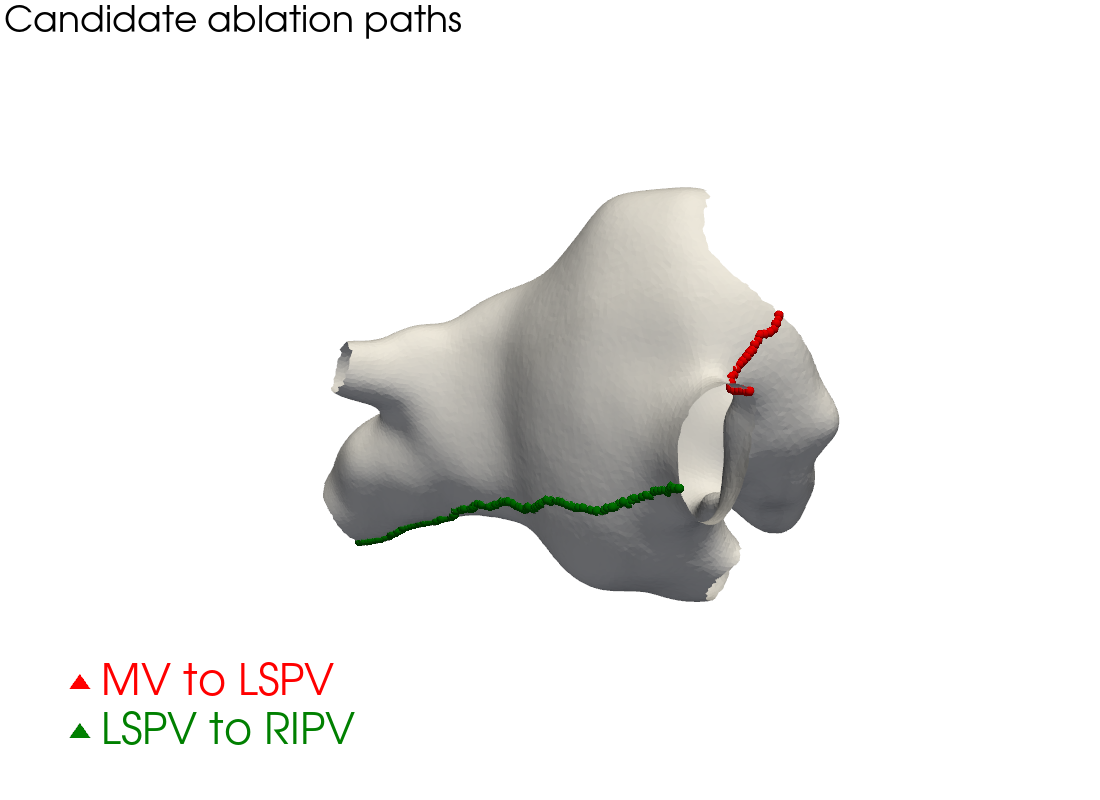

In [23]:
def closest_pair(points_a, points_b):
    from scipy.spatial import KDTree
    tree = KDTree(points_b)
    distances, indices_b = tree.query(points_a, k=1)

    index_a = np.argmin(distances)
    index_b = indices_b[index_a]

    return index_a, index_b

# find two closest points in s1 and s2
mv_lspv_closest, lspv_mv_closest = closest_pair(mv_points, lspv_points)
mv_lspv_closest = mv_point_ids[mv_lspv_closest]
lspv_mv_closest = lspv_point_ids[lspv_mv_closest]

lspv_ripv_closest, ripv_lspv_closest = closest_pair(lspv_points, ripv_points)
lspv_ripv_closest = lspv_point_ids[lspv_ripv_closest]
ripv_lspv_closest = ripv_point_ids[ripv_lspv_closest]

# find geodesic path between the two closest points using pyvista
mv_to_lspv = poly.geodesic(mv_lspv_closest, lspv_mv_closest, progress_bar=True)
mv_to_lspv_ids = mv_to_lspv.point_data["vtkOriginalPointIds"]

lspv_to_ripv = poly.geodesic(lspv_ripv_closest, ripv_lspv_closest, progress_bar=True)
lspv_to_ripv_ids = lspv_to_ripv.point_data["vtkOriginalPointIds"]

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(1100, 800))
pl.set_background("white")
pl.add_text("Candidate ablation paths", position="upper_left", font_size=16, color="black")
pl.camera_position = camera_position
pl.add_mesh(poly, color="white", opacity=1., show_edges=False)
pl.add_points(points[mv_to_lspv_ids], label="MV to LSPV", color="red", render_points_as_spheres=True, point_size=10)
pl.add_points(points[lspv_to_ripv_ids], label="LSPV to RIPV", color="green", render_points_as_spheres=True, point_size=10)
pl.add_legend(bcolor="white", loc="lower left", size=(0.28, 0.13))
pl.show()

## Give the activation pattern a position around the vein

To start a circulating wave, neighboring regions must begin at different stages of excitation and recovery. We first build a coordinate that orders those stages around the LSPV.

The heat method estimates surface distances and directions from the LSPV boundary and the MV–LSPV path. That path acts as a reference seam: the direction fields and surface normals distinguish its two sides. Together, they define the signed coordinate shown below. Beyond 20 mesh-length units from the LSPV, its value is set to -1.

The colors describe the coordinate used to initialize the wave, not voltage or physical distance.

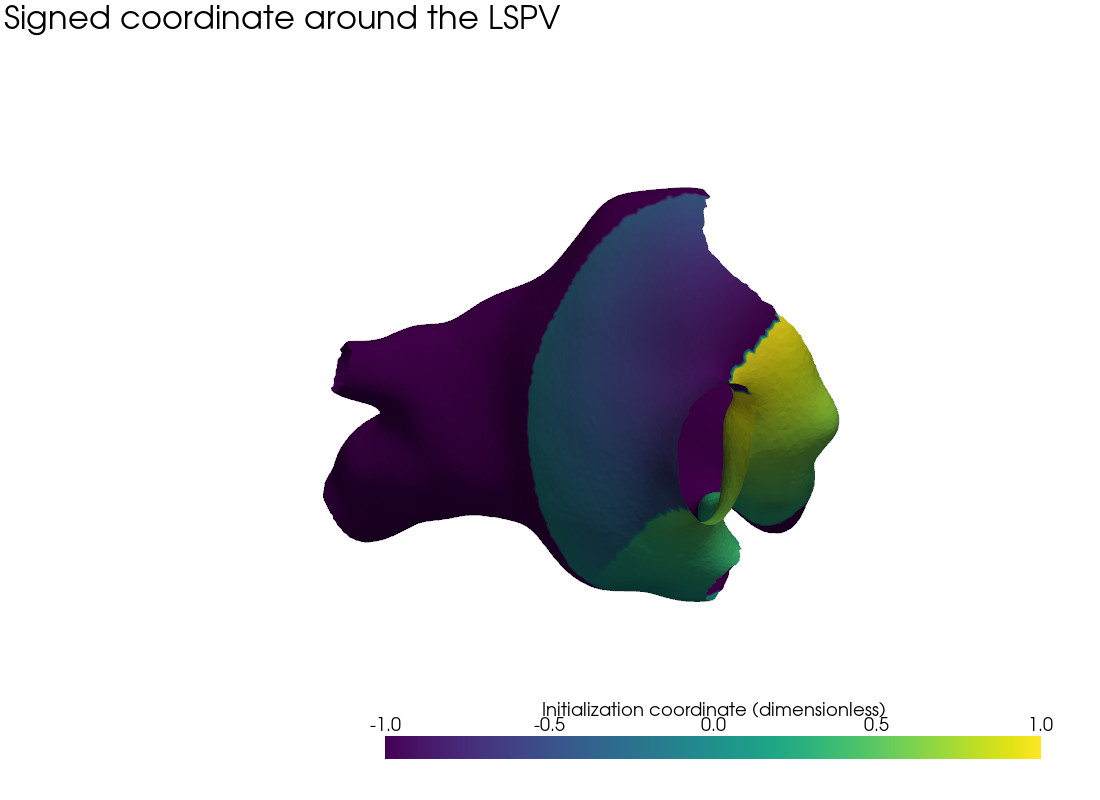

In [24]:
import numpy as np
import finitewave as fw
from finitewave_tools import linalg as fwlinalg


tissue = fw.CardiacTissueElements(points, elems, elem_type=fw.ElementType.TRIANGLE)
tissue.conductivity = 2.

spatial_discretization = fw.FiniteElementDiscretization()
K, M = spatial_discretization.compute_weights(tissue)

areas = spatial_discretization.compute_elements_size(points, elems)
G = spatial_discretization.compute_gradients(points, elems)

vec_mv = fwlinalg.distance_direction(K, M, G, elems, lspv_point_ids)
vec_circ = fwlinalg.distance_direction(K, M, G, elems, mv_to_lspv_ids)
elem_centers = np.mean(points[elems], axis=1)

vec_normal = poly.compute_normals(cell_normals=True, point_normals=False, inplace=False).cell_normals

# make sure the vectors form a right-handed coordinate system
# flip the vec_circ if it is not orthogonal to vec_mv and vec_normal
dot_product = np.einsum('ij,ij->i', vec_circ, np.cross(vec_mv, vec_normal))
vec_circ[dot_product < 0] *= -1

circ_dist = fwlinalg.geodesic_distance(K, M, G, elems, areas, mv_to_lspv_ids)
lspv_dist = fwlinalg.geodesic_distance(K, M, G, elems, areas, lspv_point_ids)

circ_dist[lspv_dist > 20] = 0.0
circ_dist = 1 - circ_dist / circ_dist.max()

# convert cell data to point data for visualization
poly["dot_product"] = dot_product
poly = poly.cell_data_to_point_data(pass_cell_data=True)
dot_product = poly.point_data["dot_product"]

circ_dist[dot_product < 0] *= -1
circ_dist[lspv_dist > 20] = -1.0

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(1100, 800))
pl.set_background("white")
pl.add_text("Signed coordinate around the LSPV", position="upper_left", font_size=16, color="black")
pl.add_mesh(poly, scalars=circ_dist, cmap="viridis", clim=(-1, 1), opacity=1,
            scalar_bar_args={"title": "Initialization coordinate (dimensionless)",
                             "color": "black", "n_labels": 5, "fmt": "%.1f"})
pl.camera_position = camera_position
pl.show()

## Turn that coordinate into a wave

We now need cellular states to place along the coordinate. Using the modified Courtemanche parameters [[2]](https://opencarp.org/documentation/examples/02_ep_tissue/03f_erp_restitution#fn3) below, we prepace a cell for two blocks of 100 beats at cycle lengths of 1000 and 500 ms. A short stimulated tissue strand then provides a 300 ms record of excitation and recovery at its midpoint.

Each atrial node receives a recorded state selected by its signed coordinate. We transfer all state variables together, so voltage and the other cellular variables come from the same moment in the recorded response. The resulting pattern is intended to initiate circulating activation near the LSPV.

The voltage plot shows our starting point. Save this state: both ablation experiments will begin here.


Running Courtemanche on (50, 1) Grid: 100%|██████████| 25000/25000 [00:03<00:00, 7400.60it/s] 


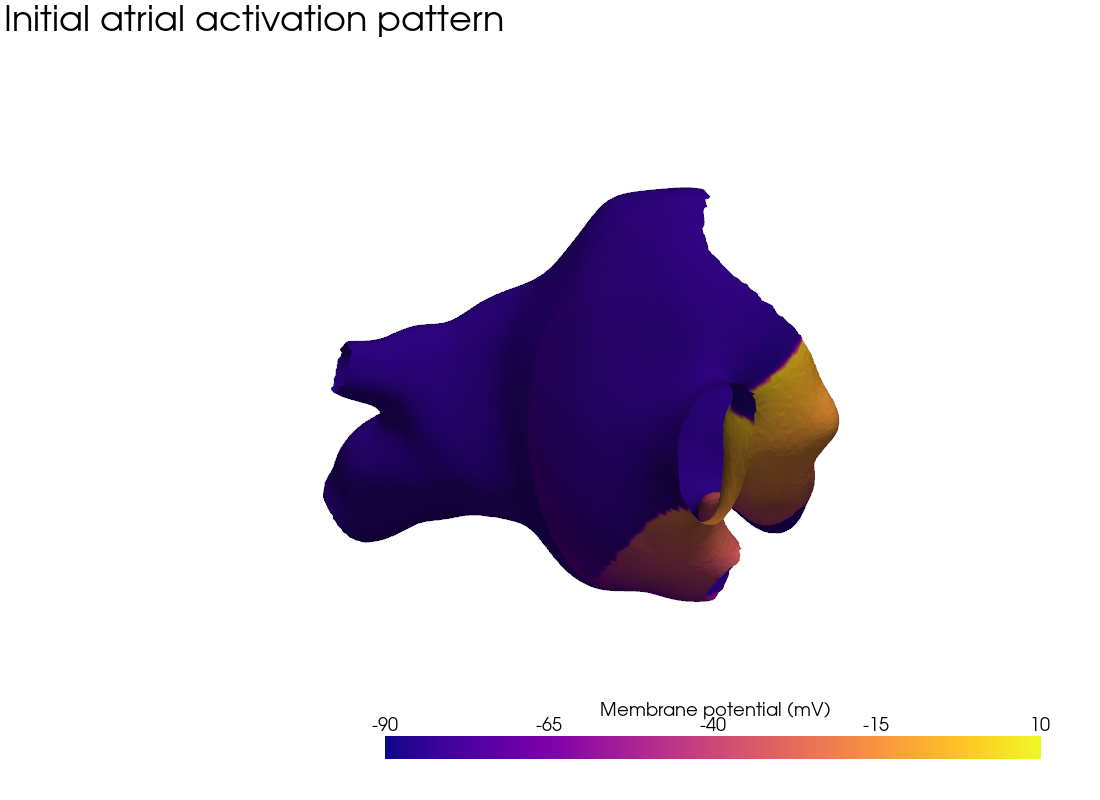

In [25]:

import numpy as np
import pyvista as pv

import finitewave as fw
import numpy as np


remodeled_params =dict(
    gk1 = 2 * 0.09,
    gks = 2 * 0.129,
    gkr = 1.6 * 0.0294,
    gkur = 0.5 * 1.0,
    gcal = 0.45 * 0.1238,
    gto = 0.35 * 0.1652,
    ipcamax = 1.5 * 0.6,
    inacamax = 1.6 * 1600.0
)

stim_prepacing = fw.StimSingleCell(dt=0.01)
stim_prepacing.add_stim(n_beats=100, cycle_length=1000, duration=1, curr_value=0.5)
stim_prepacing.add_stim(n_beats=100, cycle_length=500, duration=1, curr_value=0.5)

cardiac_model = fw.Courtemanche()
cardiac_model.set_parameters(remodeled_params)
cardiac_model.prepacing(stim_prepacing)

# create a tissue of size 50x10 to collect the state variables.
n, m = 50, 1
tissue = fw.CardiacTissue([n, m], dr=0.25)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentCoord(time=0, curr_value=100, duration=2,
                                           x_min=0, x_max=1, y_min=0, y_max=m))

state_tracker = fw.MultiVariableTracker(node_inds=[(n//2, m//2)], step=10, start_time=0)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(state_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=250, backend="numba")

simulation.cardiac_model = cardiac_model
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

state_vars = {}
n_levels = len(state_tracker.tracking_times)
state_map = n_levels - np.digitize(circ_dist, bins=np.linspace(-1, 1, n_levels))
for var_name in cardiac_model.state_vars:
    tracked_values = state_tracker.output[var_name]
    var_array = tracked_values[state_map]
    state_vars[var_name] = var_array


pv.set_jupyter_backend("static")

pl = pv.Plotter(window_size=(1100, 800))
pl.set_background("white")
pl.add_text("Initial atrial activation pattern", position="upper_left", font_size=16, color="black")
pl.camera_position = camera_position
pl.add_mesh(poly, scalars=state_vars["u"], show_edges=False, cmap="plasma", clim=(-90.0, 10.0),
            nan_color="lightgray",
            scalar_bar_args={"title": "Membrane potential (mV)",
                             "color": "black", "n_labels": 5, "fmt": "%.0f"})
pl.show()


## First experiment: connect the LSPV to the RIPV

Let the initialized wave evolve, then introduce the LSPV–RIPV lesion at 500 ms. The simulation continues to 1500 ms, giving us time to observe its response.

The `Ablate` command makes the selected nodes inactive and rebuilds the numerical system. It also sets their voltage entries to `NaN`. The lesion therefore appears instantaneously in this model. The run uses a 0.015 ms time step, backward Euler integration, and the JAX backend.

As you watch, follow activation across the whole atrium. Does it disappear after reaching the new barrier, or does a route around another opening remain active?

In [65]:


class Ablate(fw.Command):
    def __init__(self, time, ablation_ids):
        super().__init__(time=time)
        self.ablation_ids = ablation_ids

    def execute(self, simulation):
        simulation.cardiac_tissue.mesh[self.ablation_ids] = 2
        simulation.spatial_discretization.update_weights()
        simulation.time_integration.assemble_system()
        simulation.cardiac_model._u = simulation.backend.set_flat_values(
            simulation.cardiac_model._u, self.ablation_ids, np.nan
        )
        simulation.time_integration.u = simulation.backend.set_flat_values(
            simulation.time_integration.u, self.ablation_ids, np.nan
        )
        simulation.time_integration.u_old = simulation.backend.set_flat_values(
            simulation.time_integration.u_old, self.ablation_ids, np.nan
        )
        simulation.time_integration.u_old_2 = simulation.backend.set_flat_values(
            simulation.time_integration.u_old_2, self.ablation_ids, np.nan
        )


cardiac_model = fw.Courtemanche()
cardiac_model.set_parameters(remodeled_params)
cardiac_model.prepacing(stim_prepacing)
cardiac_model.set_variables(state_vars)

anim_tracker = fw.AnimationTracker(step=200, start_time=0, animation_name="lspv_to_ripv_ablation")

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.015, t_max=1500, backend="jax")
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = fw.CardiacTissue(coords=points, elems=elems,
                                             elem_type=fw.ElementType.TRIANGLE)
simulation.cardiac_model = cardiac_model
# set up time integration:
simulation.time_integration = fw.BackwardEulerTimeIntegration(atol=1e-6, maxiter=100)
simulation.tracker_sequence = fw.TrackerSequence()
simulation.tracker_sequence.add_tracker(anim_tracker)
simulation.command_sequence = fw.CommandSequence()
simulation.command_sequence.add_command(Ablate(time=500, ablation_ids=lspv_to_ripv_ids))

# run the model:
simulation.run()

# get the resulting potential at the element centers:
u = simulation.cardiac_model.u

Running Courtemanche on Triangle Elements: 100%|██████████| 99999/99999 [02:51<00:00, 582.06it/s] 


### Write animation

Export the first animation as `lspv_to_ripv_ablation`. Watch several rotations before the lesion, then follow what changes after 500 ms. A disrupted wavefront is only the immediate response; subsequent frames show whether activation continues elsewhere.

The voltage range is fixed at -82 to 10 mV so that the colors can be compared with the second experiment.

In [18]:
from pathlib import Path
import numpy as np
import finitewave_tools.visualization as fwv
import finitewave_tools.animation as fwa


animation_name = "lspv_to_ripv_ablation"

path = Path("./data")
points = np.load(path / "atrial_points.npy")
elems = np.load(path / "atrial_elems.npy")
scalar_name = "Membrane potential (mV)"
camera_position = [(-159.069, -285.733, 86.216),
                   (-33.103, -27.487, 75.834),
                   (-0.014, -0.033, -0.999)]

animation_grid = fwv.PyVistaSurfaceGrid(points, elems)

renderer = fwa.Frame3DRenderer()
renderer.set_frames(f"./{animation_name}",)
renderer.configure_grid(animation_grid, window_size=(1920, 1080))

output_dir = Path("./output")
output_dir.mkdir(parents=True, exist_ok=True)

animation = fwa.AnimationBuilder()
animation.frame_renderer = renderer
animation.write(
    path=output_dir,
    animation_name=animation_name,
    fps=24,
    prog_bar=True,
    scalar_name=scalar_name,
    camera_position=camera_position,
    cmap="plasma",
    nan_color="white",
    clim=(-90.0, 10.0),
)

video_path = output_dir / f"{animation_name}.mp4"


Building animation: 100%|██████████| 500/500 [00:08<00:00, 55.60it/s]


In [19]:
from IPython.display import Video, display

display(Video(str(video_path), embed=True, width=800))

## Second experiment: connect the MV to the LSPV

Return to the same saved cellular state and repeat the simulation, now placing the MV–LSPV lesion at 500 ms. The model parameters and timing stay the same. This is a fresh run, not a second lesion added to the first experiment.

Compare how the wave meets this barrier with its response to the LSPV–RIPV line. Both lesions involve the LSPV, but they connect different boundaries and leave different routes available.

In [ ]:
cardiac_model = fw.Courtemanche()
cardiac_model.set_parameters(remodeled_params)
cardiac_model.prepacing(stim_prepacing)
cardiac_model.set_variables(state_vars)

anim_tracker = fw.AnimationTracker(step=200, start_time=0, animation_name="mv_to_lspv_ablation")

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.015, t_max=1500, backend="jax")
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = fw.CardiacTissue(coords=points, elems=elems,
                                             elem_type=fw.ElementType.TRIANGLE)
simulation.cardiac_model = cardiac_model
# set up time integration:
simulation.time_integration = fw.BackwardEulerTimeIntegration(atol=1e-6, maxiter=100)
simulation.tracker_sequence = fw.TrackerSequence()
simulation.tracker_sequence.add_tracker(anim_tracker)
simulation.command_sequence = fw.CommandSequence()
simulation.command_sequence.add_command(Ablate(time=500, ablation_ids=mv_to_lspv_ids))

# run the model:
simulation.run()

# get the resulting potential at the element centers:
u = simulation.cardiac_model.u

### Write second animation

Export `mv_to_lspv_ablation` with the same color range and playback rate. Compare the initial circulation, the response at 500 ms, and the later activation pattern. Look for continued circulation, a change of route, or disappearance of activation during the remaining simulation.

In [ ]:
from pathlib import Path
import numpy as np
import finitewave_tools.visualization as fwv
import finitewave_tools.animation as fwa


animation_name = "mv_to_lspv_ablation"

path = Path("./data")
points = np.load(path / "atrial_points.npy")
elems = np.load(path / "atrial_elems.npy")
scalar_name = "Membrane potential (mV)"
camera_position = [(-159.069, -285.733, 86.216),
                   (-33.103, -27.487, 75.834),
                   (-0.014, -0.033, -0.999)]

animation_grid = fwv.PyVistaSurfaceGrid(points, elems)

renderer = fwa.Frame3DRenderer()
renderer.set_frames(f"./{animation_name}",)
renderer.configure_grid(animation_grid, window_size=(1920, 1080))

output_dir = Path("./output")
output_dir.mkdir(parents=True, exist_ok=True)

animation = fwa.AnimationBuilder()
animation.frame_renderer = renderer
animation.write(
    path=output_dir,
    animation_name=animation_name,
    fps=24,
    prog_bar=True,
    scalar_name=scalar_name,
    camera_position=camera_position,
    cmap="coolwarm",
    clim=(-90.0, 10.0),
)

video_path = output_dir / f"{animation_name}.mp4"


Building animation: 100%|██████████| 500/500 [00:08<00:00, 55.58it/s]


In [12]:
from IPython.display import Video, display

display(Video(str(video_path), embed=True, width=800))